<a href="https://colab.research.google.com/github/fznnfitrah/biomedika-2026/blob/main/biomedika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split, StratifiedKFold

import seaborn as sns

# **Menggunakan Dataset Biomedika**

In [ ]:
import os

# Masukkan Username dan Token Anda di sini
os.environ['KAGGLE_USERNAME'] = "23-145 ACHMAD FAUZAN ALIF FITRAH"
os.environ['KAGGLE_KEY'] = "KGAT_6a01828bd465fee4afdf7745ec5b1295"

# Install library kaggle jika belum ada
!pip install -q kaggle

# Download dataset (pastikan nama dataset sesuai dengan URL-nya)
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

# Ekstrak file zip
import zipfile
if os.path.exists('eye-diseases-classification.zip'):
    with zipfile.ZipFile('eye-diseases-classification.zip', 'r') as zip_ref:
        zip_ref.extractall('dataset_mata')
    print("Dataset berhasil diunduh dan diekstrak!")
else:
    print("File zip tidak ditemukan, cek kembali Username/Key Anda.")

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:08<00:00, 92.3MB/s]

Dataset berhasil diunduh dan diekstrak!


# **Menampilkan Data setiap kelas**

In [ ]:
# 1. SET PATH
base_dir = '/content/dataset_mata/dataset'
IMG_SIZE = 128
LIMIT_PER_CLASS = 400

In [ ]:
# 2. FUNGSI LOAD DATA DENGAN LIMIT 100
def load_data_with_visualization(directory, size, limit):
    categories = sorted(os.listdir(directory))
    X, y = [], []

    # Setup plot untuk menampilkan 5 gambar per kelas
    fig, axes = plt.subplots(len(categories), 5, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.5)

    for idx, category in enumerate(categories):
        path = os.path.join(directory, category)
        filenames = os.listdir(path)

        np.random.shuffle(filenames)

        # Ambil 100 data untuk diproses
        selected_files = filenames[:limit]
        print(f"Memuat {len(selected_files)} gambar dari kelas: {category}")

        for i, f in enumerate(selected_files):
            img_path = os.path.join(path, f)
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (size, size))

                X.append(img_resized / 255.0) # Normalisasi
                y.append(idx)

                # Tampilkan 5 gambar pertama sebagai contoh
                if i < 5:
                    axes[idx, i].imshow(img_resized)
                    axes[idx, i].axis('off')
                    if i == 2: # Beri judul di tengah kolom
                        axes[idx, i].set_title(f"Kelas: {category}", fontsize=12, fontweight='bold')

    plt.show()
    return np.array(X), np.array(y), categories

Memuat 400 gambar dari kelas: cataract
Memuat 400 gambar dari kelas: diabetic_retinopathy
Memuat 400 gambar dari kelas: glaucoma
Memuat 400 gambar dari kelas: normal


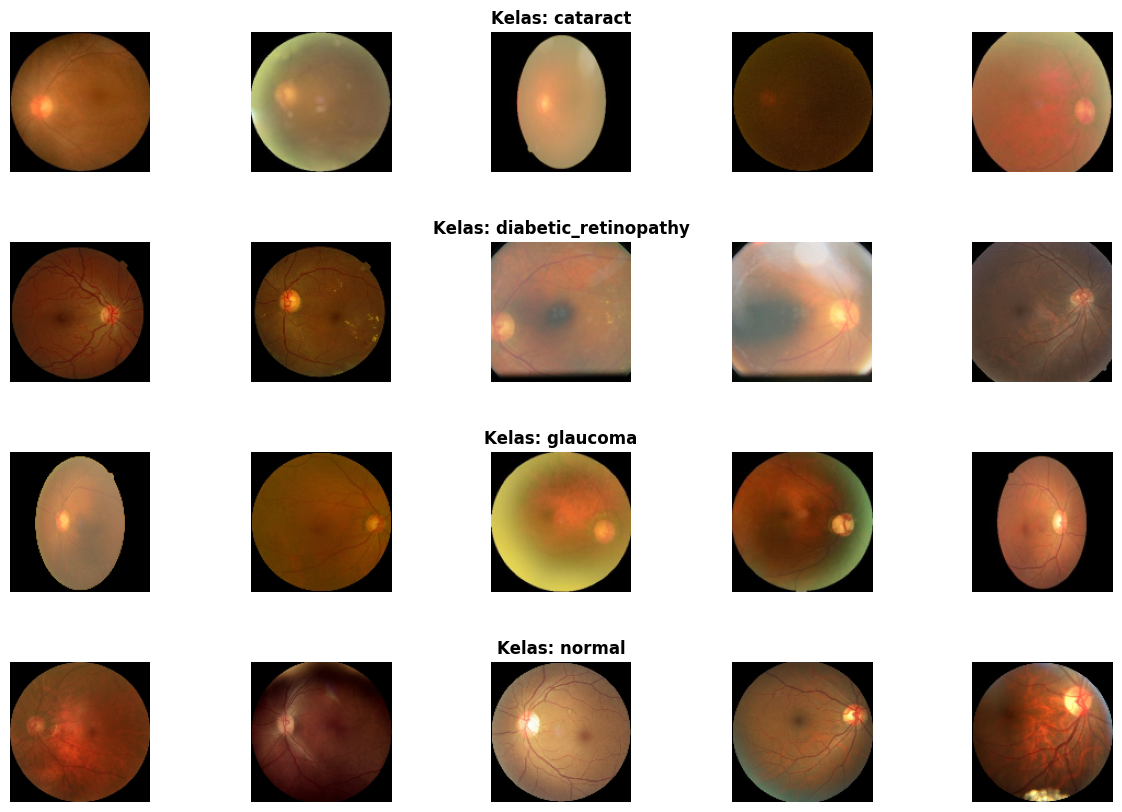


Total Data Terkumpul: 1600


In [ ]:
# 3. EKSEKUSI
X, y, label_names = load_data_with_visualization(base_dir, IMG_SIZE, LIMIT_PER_CLASS)

print(f"\nTotal Data Terkumpul: {len(X)}")

In [ ]:
print(f"Struktur Matriks X: {X.shape}") # (400, 128, 128, 3) jika ada 4 kelas

Struktur Matriks X: (1600, 128, 128, 3)


# **Split Dataset**

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"Total Data Latih & Validasi (70%): {len(X_train_val)} gambar")
print(f"Total Data Uji Independen (30%)  : {len(X_test)} gambar")



Total Data Latih & Validasi (70%): 1120 gambar
Total Data Uji Independen (30%)  : 480 gambar


In [ ]:
# Inisialisasi K-Fold untuk validasi internal di porsi 70%
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Wadah penyimpan metrik performa tiap lipatan
fold_no = 1
fold_accuracies = []

## **Proses Training Model**

In [ ]:
for train_index, val_index in skf.split(X_train_val, y_train_val):
    print("\n" + "="*60)
    print(f'TRAINING K-FOLD: FOLD KE-{fold_no}')
    print("="*60)

    # Memisahkan subset train dan validation untuk fold ini
    X_train_fold, X_val_fold = X_train_val[train_index], X_train_val[val_index]
    y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]

    # Model Arsitektur CNN (Menampilkan Konvolusi, Pooling, dan Dense)
    model = models.Sequential([
        # 1. Lapisan Ekstraksi Fitur (Convolution & Max Pooling)
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), name="Lapisan_Konvolusi_1"),
        layers.MaxPooling2D((2, 2), name="Lapisan_Max_Pooling_1"),

        layers.Conv2D(64, (3, 3), activation='relu', name="Lapisan_Konvolusi_2"),
        layers.MaxPooling2D((2, 2), name="Lapisan_Max_Pooling_2"),

        # 2. Lapisan Perataan Vektor
        layers.Flatten(name="Flattening_Matriks_ke_Vektor"),

        # 3. Lapisan Klasifikasi (Fully Connected Layer / Dense)
        layers.Dense(64, activation='relu', name="Dense_Hidden_Layer"),
        layers.Dense(len(label_names), activation='softmax', name="Output_Klasifikasi_Softmax")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Menampilkan ringkasan struktur arsitektur pada fold pertama saja
    if fold_no == 1:
        print("\n[INFO] Arsitektur Lapisan CNN:")
        model.summary()
        print("\nMemulai proses pelatihan...")

    # POIN 4: TRAINING MINIMAL 15 EPOCHS
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=15,
        batch_size=16,
        validation_data=(X_val_fold, y_val_fold),
        verbose=1
    )

    # Evaluasi internal hasil fold
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_accuracies.append(scores[1])
    print(f"\n-> Sukses! Akurasi Validasi Fold {fold_no}: {scores[1]*100:.2f}%")
    fold_no += 1

print("\n" + "="*60)
print(f"Rata-rata Akurasi Internal K-Fold: {np.mean(fold_accuracies)*100:.2f}%")
print("="*60)


TRAINING K-FOLD: FOLD KE-1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[INFO] Arsitektur Lapisan CNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Lapisan_Konvolusi_1 (Conv2D)    │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lapisan_Max_Pooling_1           │ (None, 63, 63, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lapisan_Konvolusi_2 (Conv2D)    │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lapisan_Max_Pooling_2           │ (None, 30, 30, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flattening_Matriks_ke_Vektor    │ (None, 57600)          │             0 │
│ (Flatten)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_Layer (Dense)      │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Klasifikasi_Softmax      │ (None, 4)              │           260 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,116 (14.14 MB)

 Trainable params: 3,706,116 (14.14 MB)

 Non-trainable params: 0 (0.00 B)


Memulai proses pelatihan...
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4877 - loss: 1.1864 - val_accuracy: 0.6518 - val_loss: 0.8750
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6373 - loss: 0.8163 - val_accuracy: 0.6830 - val_loss: 0.7394
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6819 - loss: 0.7309 - val_accuracy: 0.6875 - val_loss: 0.7024
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7266 - loss: 0.6444 - val_accuracy: 0.6830 - val_loss: 0.7569
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7478 - loss: 0.6080 - val_accuracy: 0.7366 - val_loss: 0.6281
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7801 - loss: 0.5454 - val_accuracy: 0.7634 - val_loss: 0.6094
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8092 - loss: 0.4582 - val_accuracy: 0.7143 - val_loss: 0.6378
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8092 - loss: 0.45

In [ ]:
print("\n[INFO] Menjalankan Pengujian Akhir Pada Data Uji Sisa (30%)...")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Menampilkan Laporan Presisi, Recall, dan F1-Score
print("\n" + "="*60)
print("CLASSIFICATION REPORT DATA UJI (30%)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=label_names))


[INFO] Menjalankan Pengujian Akhir Pada Data Uji Sisa (30%)...

CLASSIFICATION REPORT DATA UJI (30%)
                      precision    recall  f1-score   support

            cataract       0.72      0.68      0.70       120
diabetic_retinopathy       0.98      0.98      0.98       120
            glaucoma       0.65      0.58      0.62       120
              normal       0.71      0.82      0.76       120

            accuracy                           0.77       480
           macro avg       0.76      0.77      0.76       480
        weighted avg       0.76      0.77      0.76       480



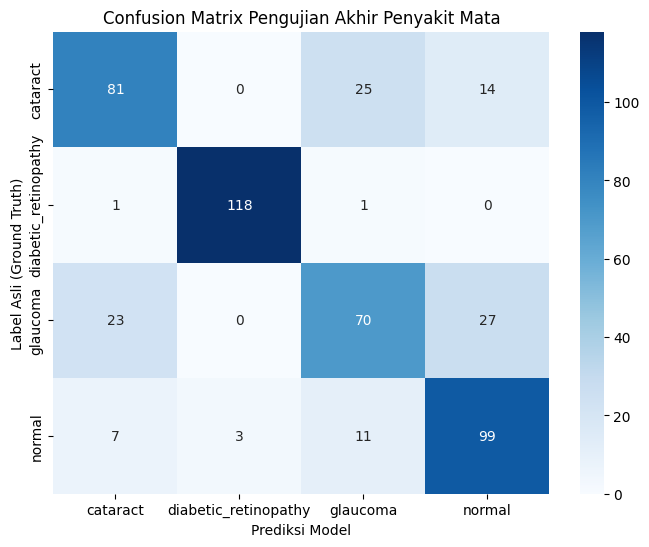

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli (Ground Truth)')
plt.title('Confusion Matrix Pengujian Akhir Penyakit Mata')
plt.show()

## 📑 DOKUMENTASI PROSES DAN EVALUASI PROYEK

---

### 1. Tahap Inisialisasi & Pengumpulan Data (Data Acquisition)

Pada tahap awal, proyek ini menggunakan dataset biomedis **Eye Diseases Classification** yang diambil secara langsung dari platform Kaggle.

* **Sumber Data:** Dataset eksternal yang dihubungkan ke Google Colab menggunakan API Token Kaggle (`KAGGLE_USERNAME` dan `KAGGLE_KEY`).
* **Kategori Citra:** Dataset ini memuat 4 kelas penyakit mata yang berbeda:
1. `Cataract` (Katarak)
2. `Diabetic Retinopathy` (Retinopati Diabetik)
3. `Glaucoma` (Glaukoma)
4. `Normal` (Mata Sehat)


* **Strategi Sampling (Randomisasi):** Untuk menjaga efisiensi memori lingkungan Colab namun tetap mempertahankan variasi data, diambil **100 gambar secara acak** (`np.random.shuffle`) dari masing-masing kelas, sehingga total data yang masuk ke dalam sistem adalah **400 citra**.

---

### 2. Tahap Pra-pemrosesan Citra (Data Preprocessing)

Sebelum citra dimasukkan ke dalam arsitektur jaringan saraf tiruan, dilakukan tiga langkah transformasi wajib menggunakan pustaka `OpenCV` dan `NumPy`:

* **Resizing:** Mengubah resolusi spasial asli gambar yang beragam menjadi ukuran seragam, yaitu **$128 \times 128$ piksel**. Ukuran ini dipilih agar fitur-fitur biomedis halus (seperti pembuluh darah retina atau keruhnya lensa) tetap terjaga tanpa membebani komputasi.
* **Color Space Conversion:** Mengonversi kanal warna dari BGR (bawaan OpenCV) menjadi **RGB** agar visualisasi gambar sesuai dengan warna aslinya.
* **Normalisasi (Min-Max Scaling):** Membagi setiap nilai piksel gambar dengan **255.0**. Langkah ini mengubah rentang nilai intensitas warna yang tadinya `0-255` (integer) menjadi skala desimal **`0.0 - 1.0`** (float). Normalisasi sangat krusial agar proses perhitungan gradien matematika saat training tidak mengalami kendala *exploding gradient*.

---

### 3. Skema Pembagian Data & Validasi (Data Splitting)

Sesuai dengan instruksi standar eksperimen yang valid, data dibagi menjadi dua bagian utama menggunakan metode *Stratified Split*:

1. **Train-Validation Set (70% - 280 Citra):** Porsi data ini dialokasikan penuh untuk proses pembelajaran model.
2. **Test Set (30% - 120 Citra):** Porsi data ini disisihkan sejak awal dan dikunci rapat. Data ini bertindak sebagai *blind test* (data uji independen) untuk mengukur kemampuan generalisasi model yang sesungguhnya di akhir program.

* **Metode K-Fold Cross Validation:** Pada porsi data 70% (Train-Val), diterapkan skema **5-Fold Cross Validation** menggunakan `StratifiedKFold`. Data 280 citra tersebut dipecah secara bergantian menjadi 5 bagian (*fold*). Di setiap perulangan, 4 bagian digunakan untuk *training* dan 1 bagian sisanya digunakan sebagai *validation*. Pendekatan *stratified* menjamin distribusi porsi kelas di setiap fold selalu seimbang (rasio kelas tetap sama).

---

### 4. Perancangan Arsitektur Model CNN (Model Architecture)

Model dieksekusi menggunakan model sekuensial (`tf.keras.models.Sequential`) dengan susunan lapisan ekstraksi fitur dan klasifikasi sebagai berikut:

* **Lapisan Konvolusi 1 (`Conv2D`):** Memiliki 32 filter berukuran $3 \times 3$ dengan fungsi aktivasi **ReLU**. Berfungsi untuk mendeteksi fitur-fitur dasar gambar (garis tepi, sudut, dan pencahayaan).
* **Lapisan Pooling 1 (`MaxPooling2D`):** Menggunakan jendela ukuran $2 \times 2$ untuk mereduksi dimensi spasial gambar menjadi setengahnya, sekaligus memberikan sifat *translation invariance* (tahan pergeseran objek).
* **Lapisan Konvolusi 2 (`Conv2D`):** Memiliki 64 filter berukuran $3 \times 3$ untuk menangkap fitur biomedis yang lebih kompleks (pola jaringan pembuluh darah atau batas optik).
* **Lapisan Pooling 2 (`MaxPooling2D`):** Melakukan reduksi dimensi tahap kedua.
* **Lapisan Perataan (`Flatten`):** Mengubah matriks fitur multi-dimensi hasil pooling terakhir menjadi sebuah **Vektor 1-Dimensi** panjang agar siap diproses oleh neuron klasifikasi.
* **Dense Hidden Layer:** Lapisan saraf tersembunyi dengan 64 neuron aktif (Aktivasi ReLU) untuk mengombinasikan fitur-fitur yang telah diekstraksi.
* **Dense Output Layer:** Memiliki 4 neuron utama (merepresentasikan 4 kelas penyakit mata) yang dipasangkan dengan fungsi aktivasi **Softmax** untuk menghasilkan distribusi probabilitas tebakan akhir model yang akumulasinya bernilai 1.0.

---

### 5. Proses Pelatihan Model (Training Phase)

Proses pelatihan dilakukan di bawah aturan ketat berikut:

* **Fungsi Loss:** Menggunakan `sparse_categorical_crossentropy` karena label target berupa bilangan bulat indeks (`0, 1, 2, 3`).
* **Optimizer:** Menggunakan `Adam` (Adaptive Moment Estimation) untuk penyesuaian *learning rate* secara dinamis selama pelatihan.
* **Jumlah Epochs:** Pelatihan dijalankan minimal **15 Epochs** pada setiap putaran fold. Artinya, model melihat dan mempelajari seluruh pola dari data latih internal sebanyak 15 kali pengulangan per fold untuk meminimalkan nilai *loss* dan memaksimalkan akurasi.

---

### 6. Tahap Pengujian & Analisis Evaluasi (Testing Phase)

Setelah siklus K-Fold selesai, model final diuji secara langsung menggunakan **Test Set (30%)** yang telah dikunci di awal. Evaluasi dilakukan secara menyeluruh dengan melahirkan dua output utama:

* **Classification Report (Precision, Recall, F1-Score):**
* *Precision* mengukur tingkat ketepatan: dari seluruh citra yang diprediksi katarak oleh model, berapa banyak yang aslinya memang katarak.
* *Recall* mengukur tingkat keberhasilan tangkapan: dari seluruh pasien yang aslinya sakit glaukoma, berapa banyak yang berhasil dideteksi oleh model.
* *F1-Score* memberikan nilai rata-rata harmonik seimbang antara presisi dan recall.


* **Visualisasi Confusion Matrix (Heatmap):**
Sebuah grafik matriks berdimensi $4 \times 4$ digambar menggunakan pustaka `Seaborn`. Sumbu Y merepresentasikan label diagnosis asli dokter (*Ground Truth*), dan Sumbu X merepresentasikan hasil tebakan dari model CNN Anda. Model dinyatakan berhasil belajar dengan sangat baik jika angka-angka tertinggi menumpuk secara sempurna di garis **Diagonal Utama** (membentuk garis miring dari pojok kiri atas ke pojok kanan bawah), yang menandakan bahwa mayoritas data uji berhasil ditebak dengan tepat tanpa mengalami bias atau salah tebak ke kelas lain.